In [13]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from difflib import SequenceMatcher
import enum

class Models(enum.Enum):
    GPT3_5 = "gpt-3.5-turbo"
    GPT4 = "gpt-4-turbo"
    GPT4o = "gpt-4o"
    LLAMA3 = "llama3-70b-8192"
    MIXTRAL8_7 = "mixtral-8x7b-32768"
    MIXTRAL8_22 = 'mixtral-8x22b-65536'

In [14]:
CWE_LIST = ["CWE-89", "CWE-22", "CWE-79"]
# MODELS = ['mixtral-8x7b-32768', 'llama3-70b-8192', 'gpt-3.5-turbo', 'gpt-4-turbo']
# MODELS = [Models.GPT4o]
MODELS = [Models.MIXTRAL8_7, Models.MIXTRAL8_22, Models.LLAMA3, Models.GPT3_5, Models.GPT4o]
INFERENCE_RESULTS_FOLDER = "./inference"
GENERATED_FILES = "./files.csv"
BUGGY_FILES_FOLDER = "./source_files"
MAX_CHARS = 20000

In [3]:
files_dict = {
    406: {
        "main_padding": "/php/406/406_whole.php",
        "buggy_content": "/php/406/406_smallestBuggy.php",
        "buggy_line": "$selectedIds = explode(',', $selectedIds);",
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    408: {
        'main_padding': '/php/408/408_whole.php',
        "additional_padding": ["/php/408/additional_padding.php"],
        "buggy_content": "/php/408/408_smallestBuggy.php",
        "buggy_line": '''SELECT * FROM ' . static::table_name() . ' WHERE ' . $property .  ''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    405: {
        'main_padding': '/php/405/405_whole.php',
        "additional_padding": ["/php/405/additional_padding.php"],
        "buggy_content": "/php/405/405_smallestBuggy.php",
        "buggy_line": '''$where = "WHERE group_ID = {$group_id}";''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4921: {
        'main_padding': '/go/4921/4921_modifiedFile.go',
        "additional_padding": ["/go/4921/additional_padding.go"],
        "buggy_content": "/go/4921/4921_smallestBuggy.go",
        "buggy_line": '''order := fmt.Sprintf("`%s` %s", DefaultQuery(c, "sort_by", "id"), sort)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4928: {
        'main_padding': '/php/4928/4928_modifiedFile.php',
        "additional_padding": ["/php/4928/additional_padding.php"],
        "buggy_content": "/php/4928/4928_smallestBuggy.php",
        "buggy_line": '''return @mysqli_real_escape_string($fmdb->dbh, $data);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    3989:{
        'main_padding': '/js/3989/3989_whole.js',
        "additional_padding": ["/js/3989/additional_padding.js"],
        "buggy_content": "/js/3989/3989_smallestBuggy.js",
        "buggy_line": '''`window[${idJSON}].push(${serializedCacheArgs});`,''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3976:{
        'main_padding': '/js/3976/3976_whole.js',
        "additional_padding": ["/js/3976/additional_padding.js"],
        "buggy_content": "/js/3976/3976_smallestBuggy.js",
        "buggy_line": '''const header = container.querySelector(`h${level}`);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3968:{
        'main_padding': '/php/3968/3968_whole.php',
        "additional_padding": ["/php/3968/additional_padding.php"],
        "buggy_content": "/php/3968/3968_smallestBuggy.php",
        "buggy_line": '''$response['data']['path'] = $model->path;''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    300:{
        'main_padding': '/php/300/300_modifiedFile.php',
        "additional_padding": ["/php/300/additional_padding.php"],
        "buggy_content": "/php/300/300_smallestBuggy.php",
        "buggy_line": '''<td>' . $item->id . '</td>''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    302:{
        'main_padding': '/rb/302/302_modifiedFile.rb',
        "additional_padding": ["/rb/302/additional_padding.rb"],
        "buggy_content": "/rb/302/302_smallestBuggy.rb",
        "buggy_line": '''@filter = params[:filter] || "*"''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-79"
    },
    5422:{
        'main_padding': '/go/5422/5422_modifiedFile.go',
        "additional_padding": ["/go/5422/additional_padding.go"],
        "buggy_content": "/go/5422/5422_smallestBuggy.go",
        "buggy_line": '''outdir := filepath.Join(basePath, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5396:{
        'main_padding': '/java/5396/5396_modifiedFile.java',
        "additional_padding": ["/java/5396/additional_padding.java"],
        "buggy_content": "/java/5396/5396_smallestBuggy.java",
        "buggy_line": '''URI uri = toURI(fileUri);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5404:{
        'main_padding': '/go/5404/5404_modifiedFile.go',
        "additional_padding": ["/go/5404/additional_padding.go"],
        "buggy_content": "/go/5404/5404_smallestBuggy.go",
        "buggy_line": '''target := filepath.Join(dst, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5414:{
        'main_padding': '/js/5414/5414_modifiedFile.js',
        "additional_padding": ["/js/5414/additional_padding.js"],
        "buggy_content": "/js/5414/5414_smallestBuggy.js",
        "buggy_line": '''var filename = path.join(__dirname, "public", req.url.path_list.join("/"));''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    493:{
        'main_padding': '/py/493/493_modifiedFile.py',
        "additional_padding": ["/py/493/additional_padding.py"],
        "buggy_content": "/py/493/493_smallestBuggy.py",
        "buggy_line": '''return FileResponse(f"user_images/pfp/{username}", media_type='image/gif')''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-22"
    },
}

# Import CSV

In [15]:
def import_csv(cwe_list, models):
    df_files = pd.read_csv(GENERATED_FILES)
    df_files = df_files[df_files['target_length'] <= MAX_CHARS]

    combined_df = pd.DataFrame()

    for model in models:
        df_model = pd.read_csv(INFERENCE_RESULTS_FOLDER+"/"+model.value+".csv")
        for cwe_id in cwe_list:
        
            print(f"Processing CWE {cwe_id} for model {model}")
            df_cwe = df_files[(df_files['CWE_ID'] == cwe_id)]

            if len(df_cwe) == 0:
                print(f"No files found for CWE {cwe_id}")
                continue

            df_combined = pd.merge(df_model, df_cwe, on='file_id', how='inner')

            _check_files(df_model, df_cwe)


            combined_df = pd.concat([combined_df, df_combined])

    combined_df = combined_df[['content', 'model_output', 'prompt', 'file_id', 'database_file_id', 'length', 'bug_position', 'target_bug_position', 'target_length', 'CWE_ID', 'model']]
    
    return combined_df

# Check files function
def _check_files(df_data, df_files):
    file_ids_data = df_data['file_id'].value_counts()
    file_ids_files = df_files['file_id'].unique()

    problems = []
    for file_id in file_ids_files:
        if file_id not in file_ids_data or file_ids_data[file_id] != 1:
            problems.append(file_id)
        
    if len(df_data) != len(df_files):
        print(f"Data count mismatch: Expected {len(df_files)}, got {len(df_data)}.")

    if problems:
        print(f"Some file_ids are missing the required number of entries in the data:")
        for file_id in problems:
            count = file_ids_data[file_id] if file_id in file_ids_data else 0
    else:
        print("All file_ids have the correct number of entries.")


# Extracting functions

In [5]:
def extract_code_or_return_original(text):
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        return text

    results = []
    for match in matches:
        results.append(match.group(2).strip())

    return "\n".join(results)

def clean_whitespace(text):
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    bug_line = extract_code_or_return_original(bug_line).strip()

    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    _has_bug_line = bool(bug_line_pattern.search(model_output))

    if not _has_bug_line:
        return False
    
    bug_line = extract_bug_line(model_output)
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

# Clean patch function
def clean_patch(patch):
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

In [6]:
def load_buggy_file(filepath):
    with open(BUGGY_FILES_FOLDER+filepath, 'r') as file:
        return file.read()

In [7]:
def classify(record, file_dict):
    model_output = record['model_output']

    classification = None
    bug_line = None
    bug_line_in_content = False

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    if has_bug_false_indication: 
        classification = 'FN'
    elif not _has_bug_line:
        classification = 'FN'
    else:
        bug_line = remove_spaces(extract_bug_line(model_output))

        buggy_content = remove_spaces(load_buggy_file(file_dict[record['database_file_id']]['buggy_content']))
        
        if bug_line in buggy_content:
            bug_line_in_content = True
            
        
        if (len(bug_line) > 0 and bug_line_in_content):
            classification = 'TP'
        else:
            classification = 'FP' 
        
    return pd.Series([classification, bug_line])

# Prepare dataframe function
def prepare_df(df, file_dict):
    df[['classification', 'bug_line']] = df.apply(lambda record: classify(record, file_dict), axis=1)
    return df

# Execution

In [21]:
combined_df = import_csv(CWE_LIST, MODELS)
df = prepare_df(combined_df, files_dict)

Processing CWE CWE-89 for model Models.MIXTRAL8_7
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-22 for model Models.MIXTRAL8_7
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-79 for model Models.MIXTRAL8_7
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-89 for model Models.MIXTRAL8_22
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-22 for model Models.MIXTRAL8_22
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-79 for model Models.MIXTRAL8_22
Data count mismatch: Expected 280, got 840.
All file_ids have the correct number of entries.
Processing CWE CWE-89 for model Models.LLAMA3
Data count mismatch: Expected 280, got 1008.
All file_ids have the correct number of entries.

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def generate_heatmaps(data, group_by, title_suffix='', save_path='./plots'):
    # Define the classification mapping and colors
    colors = ["red", "white", "green"]
    nodes = [0.0, 0.5, 1.0]
    cmap = mcolors.LinearSegmentedColormap.from_list("", list(zip(nodes, colors)))
    norm = mcolors.Normalize(vmin=-1, vmax=1)

    groups = data.groupby(group_by)

    for name, group in groups:
        matrix, x_labels, y_labels, annotations = create_classification_matrix(group)
        title = f"{title_suffix} - {name}"
        plot_heatmap(matrix, x_labels, y_labels, annotations, cmap, norm, title, save_path)

def create_classification_matrix(df):
    classification_mapping = {'TP': 1, 'FP': -1, 'TN': 0, 'FN': -1}
    # Create mappings based on unique entries in 'target_bug_position' and 'target_length'
    bug_pos_mapping = {val: idx for idx, val in enumerate(sorted(df['target_bug_position'].unique()))}
    file_char_mapping = {val: idx for idx, val in enumerate(sorted(df['target_length'].unique()))}
    
    # Initialize the matrix and count matrix
    matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))
    count_matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))

    # Populate matrix and count matrix
    for _, row in df.iterrows():
        file_idx = file_char_mapping[row['target_length']]
        bug_idx = bug_pos_mapping[row['target_bug_position']]
        classification_value = classification_mapping[row['classification']]
        matrix[file_idx][bug_idx] += classification_value
        count_matrix[file_idx][bug_idx] += 1

    # Calculate averages and prepare annotations
    annotations = np.zeros_like(matrix, dtype=object)
    for i in range(len(file_char_mapping)):
        for j in range(len(bug_pos_mapping)):
            if count_matrix[i][j] > 0:
                avg_value = matrix[i][j] / count_matrix[i][j]
                matrix[i][j] = avg_value
                annotations[i][j] = f"{avg_value:.2f} \n ({int(count_matrix[i][j])})"
            else:
                annotations[i][j] = ""

    return matrix, list(bug_pos_mapping.keys()), list(file_char_mapping.keys()), annotations

def plot_heatmap(matrix, x_labels, y_labels, annotations, cmap, norm, title, save_path):
    plt.figure(figsize=(20, 2))
    sns.heatmap(matrix, annot=annotations, fmt="", cmap=cmap, norm=norm, xticklabels=x_labels, yticklabels=y_labels)
    plt.title(title)
    plt.xlabel('Bug Positions')
    plt.ylabel('File Characters')
    # plt.savefig(f"{save_path}/heatmap_{title.replace(' ', '_')}.png")
    plt.show()

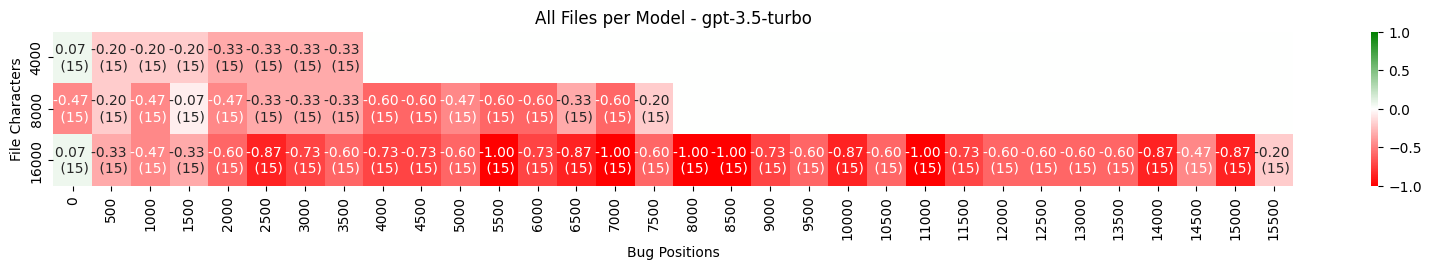

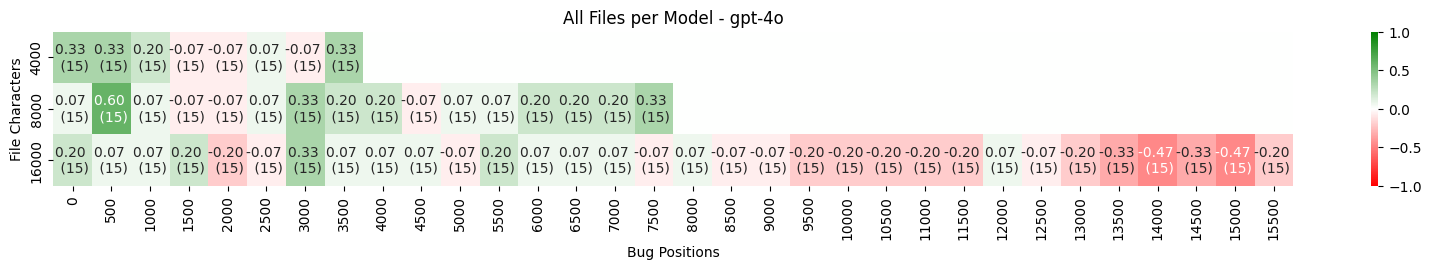

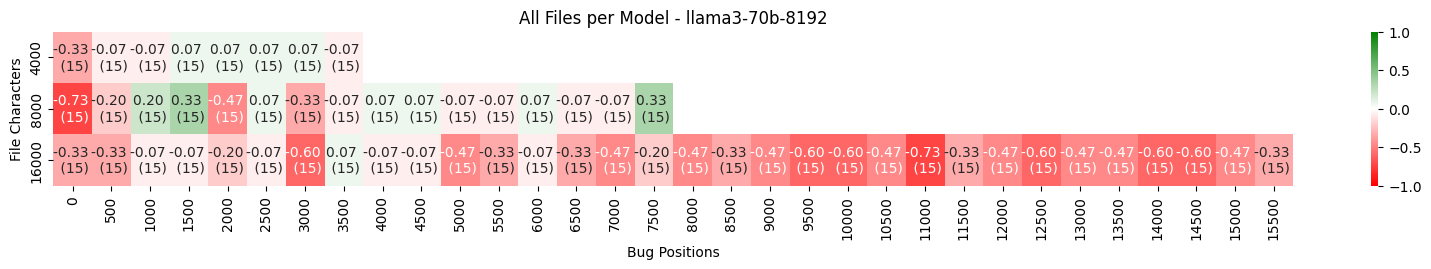

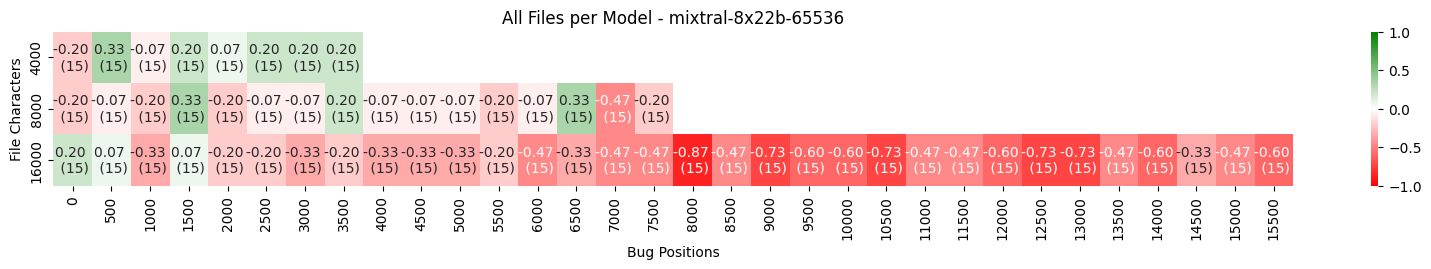

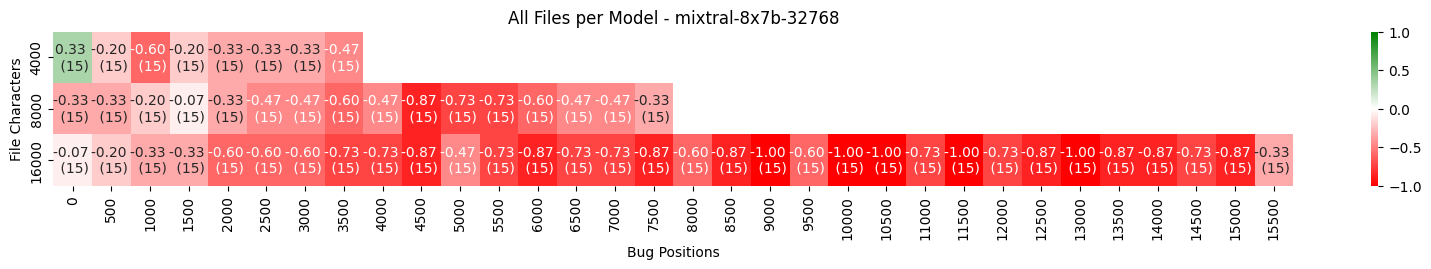

In [22]:
generate_heatmaps(df, 'model', 'All Files per Model')
# generate_heatmaps(df[df['CWE_ID']=='CWE-89'], 'model', 'CWE-89 per Model')
# generate_heatmaps(df, ['CWE_ID'], 'All Models by CWE')

# Logistical Regression TODO - not completed yet

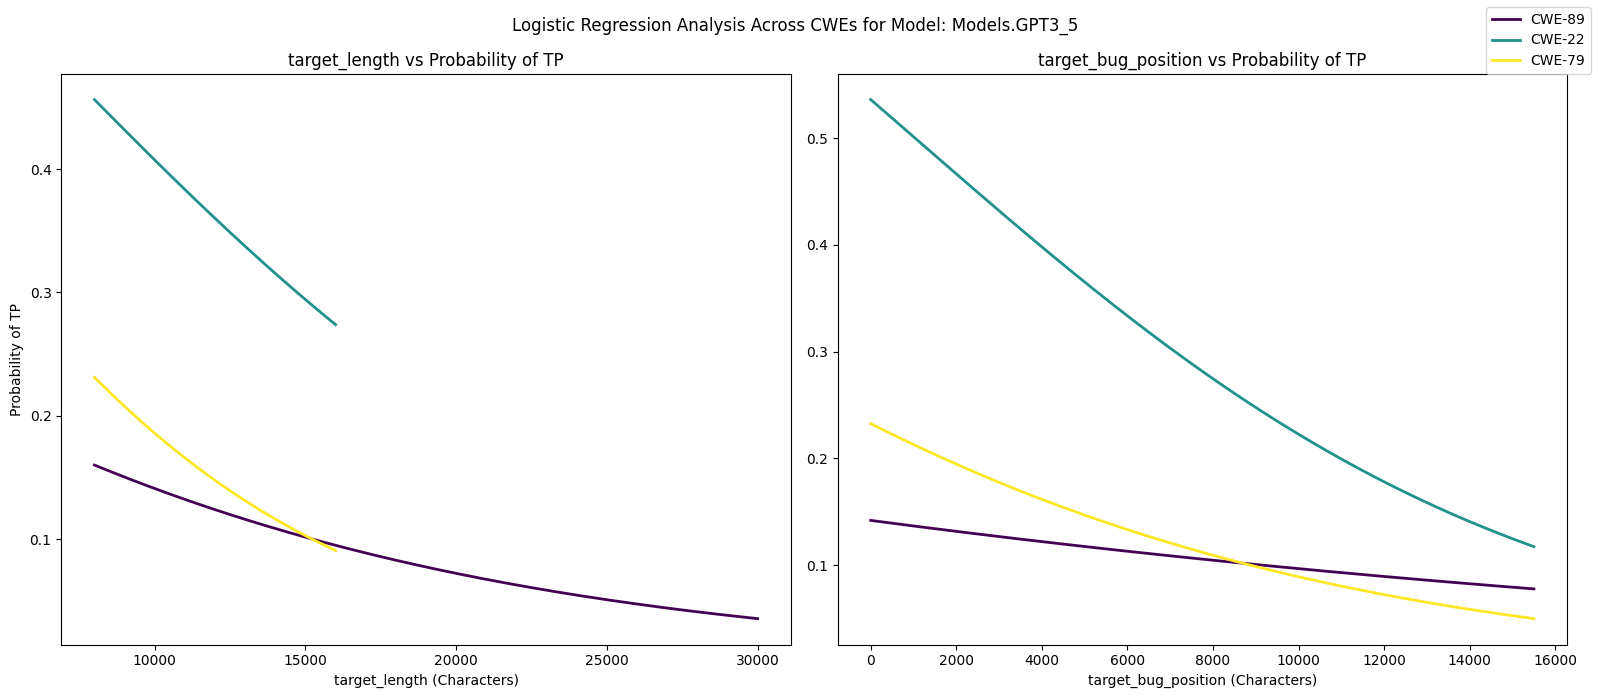

In [17]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

def plot_logistic_regressions_for_model(df, model, features, cwe_ids, target_variable, save_path='./plots'):
    # Get dummy variables for all CWE IDs
    df = pd.get_dummies(df, columns=['classification'], drop_first=False)
    
    fig, axes = plt.subplots(1, len(features), figsize=(16, 7), dpi=100)
    colors = plt.cm.viridis(np.linspace(0, 1, len(cwe_ids)))  # Generate a color array

    for i, feature in enumerate(features):
        for cwe_id, color in zip(cwe_ids, colors):
            cwe_df = df[df['CWE_ID'] == cwe_id]
            if not cwe_df.empty:
                plot_logistic_regression(cwe_df, feature, target_variable, cwe_id, axes[i], color)
        axes[i].set_xlabel(f'{feature} (Characters)')
        axes[i].set_title(f'{feature} vs Probability of TP')

    axes[0].set_ylabel('Probability of TP')
    fig.suptitle(f'Logistic Regression Analysis Across CWEs for Model: {model}')
    fig.legend(cwe_ids, loc='upper right')
    plt.tight_layout()
    # plt.savefig(f"{save_path}/logistic_regression_{model}_all_cwes.png")
    plt.show()

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    model = sm.Logit(y, X).fit(disp=0)
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    y_probs = model.predict(sm.add_constant(x_values))
    
    ax.plot(x_values, y_probs, label=f"{label} (p={model.pvalues[x_col]:.5f})", color=color, linewidth=2)

# Example of usage
cwe_ids = ['CWE-89', 'CWE-22', 'CWE-79']  # Example CWE IDs
plot_logistic_regressions_for_model(df, Models.GPT3_5, ['target_length', 'target_bug_position'], cwe_ids, 'classification_TP')

# Classification

In [12]:
# df group by file_nr and display count of clasification
df_grouped = df.groupby(["CWE_ID",'database_file_id', 'classification', ]).size().unstack(fill_value=0)
df_grouped

classification           FN   FP   TP
CWE_ID database_file_id              
CWE-22 493                7  151  117
       5396              43   39  198
       5404              20  133  127
       5414               0   84  196
       5422               9  193   78
CWE-79 300                0  267   13
       302               35   92  153
       3968              17  215   48
       3976              27   95  158
       3989              23  192   65
CWE-89 405               14  195  127
       406               13  202  147
       408               41  269   26
       4921               0  264   16
       4928               8  262   10

Outliers for CWE-89 are below -15941.0 or above 32075.0 34073.0


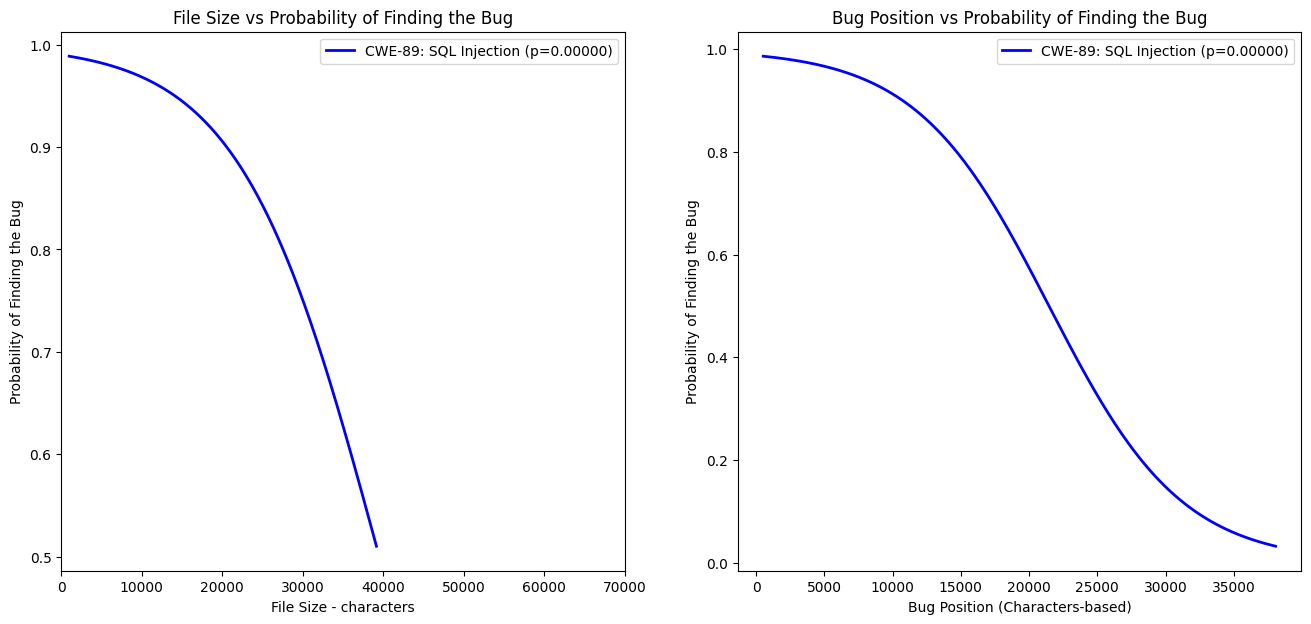

In [ ]:
import numpy as np
import statsmodels.api as sm

def calculate_outlier_thresholds(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)
    label_dict = {
        "CWE-22": "CWE-22: Path Traversal",
        "CWE-89": "CWE-89: SQL Injection",
        "CWE-79": "CWE-79: XSS"
    }

    # Plot
    ax.plot(x_values, y_probs, label=f"{label_dict[label]} (p={model.pvalues[x_col]:.5f})", color=color, linewidth=2)
    
    return model

target_variable = 'classification_TP'
cwe = f'CWE-{CWE}'

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
colors = ['blue', 'orange', 'green']

df = pd.get_dummies(df, columns=['classification'], drop_first=False)

# drop NA for some files (like 1 or 2 files overall)
df = df.dropna(subset=['total_length'])

# filter only TP and FN
df = df[(df['classification_TP'] == 1) | (df['classification_FN'] == 1)]

thresholds = calculate_outlier_thresholds(df['bug_pos'])
print(f"Outliers for {cwe} are below {thresholds[0]} or above {thresholds[1]}", df['bug_pos'].quantile(0.99))
df = df[df['bug_pos'] <= 2*thresholds[1]]

plot_logistic_regression(df, 'total_length', target_variable, cwe, axes[0], colors[0])
plot_logistic_regression(df, 'bug_pos', target_variable, cwe, axes[1], colors[0])

axes[0].set_xlabel('File Size - characters')
axes[0].set_ylabel('Probability of Finding the Bug')
axes[0].set_title('File Size vs Probability of Finding the Bug')
axes[0].set_xlim([0, 70000])
axes[0].legend()

axes[1].set_xlabel('Bug Position (Characters-based)')
axes[1].set_ylabel('Probability of Finding the Bug')
axes[1].set_title('Bug Position vs Probability of Finding the Bug')
axes[1].legend()
# save into plots
plt.savefig(f'./plots/logistic_regression_{CWE}_{MODEL}.png')